<>:305: SyntaxWarning: invalid escape sequence '\p'
<>:305: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_16882/1780422931.py:305: SyntaxWarning: invalid escape sequence '\p'
  plt.bar(np.arange(n)+0.1,A.dot(x),color='r',width=0.2, label="puissance effective $\pi_i$")


Résolution du système avec la méthode LU :
[[0.66155936]
 [0.30785679]
 [0.36468892]
 [0.34324692]
 [0.34223233]
 [0.33902151]
 [0.33745496]
 [0.3363203 ]
 [0.33565385]
 [0.33533442]
 [0.33533442]
 [0.33565385]
 [0.3363203 ]
 [0.33745496]
 [0.33902151]
 [0.34223233]
 [0.34324692]
 [0.36468892]
 [0.30785679]
 [0.66155936]]
Résolution du système avec la méthode adaptée :
[0.65238565 0.30313717 0.35892493 0.33745583 0.33610662 0.33254744
 0.3305577  0.32892871 0.32767994 0.32666958 0.32584003 0.32514546
 0.3245555  0.32404803 0.32360682 0.32321963 0.32287709 0.32257185
 0.32229813 0.32205126 0.32182746 0.32162364 0.32143723 0.32126608
 0.32110838 0.32096261 0.32082746 0.3207018  0.32058467 0.32047523
 0.32037274 0.32027657 0.32018613 0.32010094 0.32002054 0.31994455
 0.31987262 0.31980441 0.31973966 0.31967811 0.31961952 0.31956369
 0.31951042 0.31945955 0.31941091 0.31936436 0.31931977 0.31927702
 0.319236   0.3191966  0.31915873 0.31912231 0.31908724 0.31905346
 0.3190209  0.3189895  0.

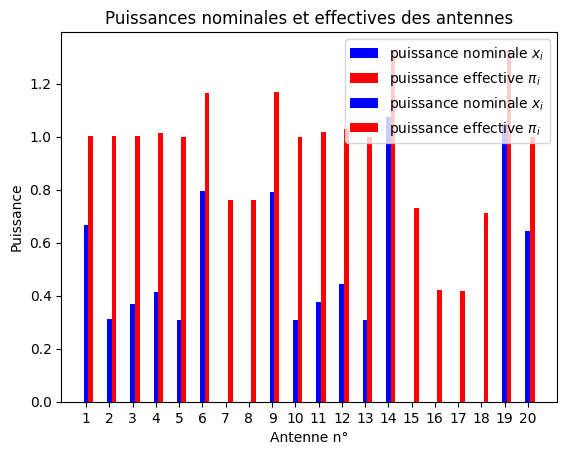

In [1]:
#!/usr/bin/env python3
# coding: utf-8

import numpy as np
import copy as cp
import matplotlib.pyplot as plt 

def V(r,r0):
    """
    Fonction mesurant la pertr de puissance du signal en fonction de la distance
    """
    return 1/(1+(r/r0)**2)

def W(r):
    """
    Fonction mesurant la perte de puissance du signal en fonction de la distance. 
    On a W(r)=V(r*r0) avec V définie comme dans l'énoncé.
    """
    return 1/(1+r**2)

"""
Question 3
"""

"""
version 1
"""
def MatriceA(n,tau):
    """
    n : Taille de la matrice carrée A
    tau : d/r0
    
    Renvoie la matrice A définie par (4)
    """
    A = np.eye(n)
    #on commence par faire une boucle sue les lignes pour remplir la partie
    #supérieure de la matrice
    for i in range(n-1):
        for j in range(1,n-i):
            A[i,i+j]=W(j*tau)
    #comme la matrice attendue est symétrique, il reste juste à ajouter à notre
    #matrice A sa transposée pour obtenir sa partie inférieure et à soustraire
    #la matrice identitée pour avoir une diagonale de 1
    A = A + A.T - np.eye(n)
    return A

"""
version 2
"""
def MatriceA_v2(n,tau):
    """
    n : Taille de la matrice carrée A
    tau : d/r0
    
    Renvoie la matrice A définie par (4)
    """
    A=np.eye(n)
    for i in range(n):
        for j in range(n):
            A[i,j] = W(abs(i-j)*tau)
    return A

"""
version 3
"""
def MatriceA_v3(n,tau):
    """
    n : Taille de la matrice carrée A
    tau : d/r0
    
    Renvoie la matrice A définie par (4)
    """
    A = np.eye(n)
    for i in range(n-1):
        for j in range(i+1,n):
            A[i,j] = W(abs(i-j)*tau)
    A = A + A.T - np.eye(n)
    return A

"""
version 1:
    %timeit MatriceA(100,1)
-> 5.41 ms ± 302 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
    %timeit MatriceA(1000,1)
-> 548 ms ± 31.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

version 2:
    %timeit MatriceA_v2(100,1)
-> 8.91 ms ± 1.57 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
    %timeit MatriceA_v2(1000,1)
-> 1.15 s ± 102 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

version 3:
    %timeit MatriceA_v3(100,1)
-> 5.98 ms ± 249 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
    %timeit MatriceA_v3(1000,1)
-> 643 ms ± 44.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

On remarque que la version 1 de ce programme est plus efficace et plus rapide
que les versions 2 et 3 de ce programme, au prix d'une lisibilité du programme
diminuée.
On utilisera la version 1 de la fonction MatriceA dans la suite du programme.
"""

def remontee(A,b):
    """
    A : matrice carée triangulaire supérieure de taille n*n
    b : vecteur colonne de taille n
    
    Retourne le vecteur solution de l'équation Ax=b
    """
    n,m = np.shape(A)
    x=cp.deepcopy(b)
    for i in range(n-1,-1,-1):
        x[i] = x[i] - np.dot(A[i,i+1:n],x[i+1:n])
        x[i] = x[i]/A[i,i]
    return x

def descente(A,b):
    """
    A : matrice carée triangulaire inférieure de taille n*n
    b : vecteur colonne de taille n
    
    Retourne le vecteur solution de l'équation Ax=b
    """
    n,m=np.shape(A)
    x=cp.deepcopy(b)
    for i in range (0,n):
        x[i]=x[i]-np.dot(A[i,0:i],x[0:i])
        x[i]=x[i]/A[i,i]
    return x

def Gauss(A):
    """
    Retourne la reduite triangulaire de Gauss naturelle avec stockage des 
    coefficients m_i,k a la place des zeros
    On suppose qu'aucun pivot n'est nul
    """
    n,m = np.shape(A)
    T=cp.deepcopy(A)
    for k in range(n-1):
        for i in range(k+1,n):
            T[i,k]=-T[i,k]/T[k,k]
            T[i,k+1:] = T[i,k+1:] + T[i,k]*T[k,k+1:]
    return T

def LU(A):
    """
    Retourne la décomposition LU de la matrice A
    """
    n,m = np.shape(A)
    T = Gauss(A)
    U = np.triu(T)
    L = U - T + np.eye(n)
    return L,U

def res_LU(A,b):
    """
    Retourne le vecteur solution de l'équation Ax=b
    """
    L,U = LU(A)
    return remontee(U, descente(L,b))

def test_q3():
    n=20
    tau=1
    A = MatriceA(n,tau)
    b = np.array([1. for i in range(n)])
    b = np.reshape(b,(n,1))
    x=res_LU(A,b)
    print('Résolution du système avec la méthode LU :',x,sep='\n')

test_q3()

"""
n=20
%timeit res_LU(A,b)
3.41 ms ± 295 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)

n=1000
%timeit res_LU(A,b)
7.57 s ± 162 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
"""

"""
Question 4
"""

def Etape1(t):
    """
    t : vecteur caractérisant une matrice Toeplitz
    
    Retourne la suite de vecteurs (f1,...,fn) définie dans la première étape
    de résolution. Ce vecteur est stocké dans une liste.
    """
    f=np.array([1/t[0]])
    F=[f]
    s=np.array([0,1])
    for i in range(2,len(t)+1):
        #calcul du dk
        dk=np.dot(t[1:i],f)
        #recherche de ak et bk
        ak,bk=np.linalg.solve(np.array([[1,dk],[dk,1]]),s)
        #on actualise f
        f=ak*np.append(f[::-1],[0])+bk*np.append([0],f)
        #et on ajoute f dans la suite de vecteurs
        F.append(f)
    return F

def Etape2(t,b):
    """
    t : vecteur caractérisant une matrice Toeplitz
    b : vecteur
    
    Retourne la solution x de l'équation Tx=b
    """
    F=Etape1(t)
    x=np.array([b[0]/t[0]])
    for fk in F[1:]:
        tetak=b[len(fk)-1]-np.dot(t[1:len(fk)],x[::-1])
        x=np.append(x,[0])+tetak*fk
    return x
    
    
def test_q4():
    n=1000
    tau=1
    t=[W(tau*i) for i in range(n)]
    b = np.array([1. for i in range(n)])
    x=Etape2(t,b)
    print('Résolution du système avec la méthode adaptée :',x,sep='\n')

test_q4()

"""
n=20
%timeit Etape2(t,b)
3.25 ms ± 357 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)

n=1000
%timeit Etape2(t,b)
396 ms ± 30.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

On remarque que la méthode adaptée au contexte est effectivement plus rapide
que la résolution par la méthode LU. La seconde méthode permet de plus d'éviter
le calcul de la matrice A.
"""

"""
Questions 5-6
""" 

def ProjI(x,I) :#retourne PAP
    """
    x : Vecteur de R^n ou matrice de M_n(R)
    I : Liste ordonnée d'un sous ensemble de {0,1,2,....n-1} 
    
    Renvoie le vecteur (respectivement la matrice) x tel.le que l'on a enlevé les composantes 
    (respectivement les colonnes et les lignes) d'indice n'étant pas dans I                            
    """
    if len(np.shape(x))==1 : return x[I]
    if len(np.shape(x))==2 : return x[I][:,I]


def Projn(y,I,n) : #retourne Pb ou P*pi
    """
    n : entier naturel >=1
    I : Liste ordonnée d'un sous ensemble de {0,1,2,....n-1} 
    y : Vecteur de R^l où l est le cardinale de I 
        
    Renvoie le vecteur x tel que x[I]=y et x[i]=0 si i n'est pas dans I. 
    Dans le dossier cela correspond à rentrer y tilde pour renvoyer y.                          
    """    
    x=np.zeros(n)
    k=0
    for i in range(n) : 
        if i in I : 
            x[i]=y[k]
            k+=1
    return x

    
def SolveReseauPartiel(A,I,b):
    """
    b : Vecteur de R^n
    A : Matrice symétrique définie positive de M_n(R)
    I : Liste ordonnée du sous ensemble de {0,1,2,....n-1} correspondant aux numéros des antennes en pannes avec 
    un décalage de -1 par rapport aux vrais numéros (par exemple si 4 est dans I alors il correspond à l'antenne n°5).
                                   
    Renvoie la solution de l'équation PAPx=Pb sous la contrainte Px=x où P est la matrice de projection sur I
    """
    n=len(b)
    A,b=ProjI(A,I),ProjI(b,I)
    x=res_LU(A,b)
    x=Projn(x,I,n) #On met en oeuvre la contrainte
    return x


def Graphepuissances(A,x) :
    """
    Affiche le graphe des puissances nominales et effectives par antenne
    """
    n=len(x)
    plt.bar(np.arange(n)-0.1,x,color='b',width=0.2, label="puissance nominale $x_i$",tick_label=range(1,n+1)) #width=0.8 par defaut (tick_label=names)
    plt.bar(np.arange(n)+0.1,A.dot(x),color='r',width=0.2, label="puissance effective $\pi_i$")
    plt.title('Puissances nominales et effectives des antennes')
    plt.xlabel("Antenne n°")
    plt.ylabel("Puissance")
    plt.legend()


#Réponse à la question 5.2 et 5.3 : 

n,tau=20,1 #d=r0 <=> tau=1 
A=MatriceA(n,tau)
IP=[6,7,14,15,16,17] #-1 partout car Python compte à partir de 0
I=[i for i in range(20) if i not in IP ]
pi=np.ones(20)
x=SolveReseauPartiel(A,I,pi) #Solution du problème "CA VAUT pour LES ANTENNES QUI MARCHENT PAS"
print(x,A.dot(x)) #Affiche les puissances nominales et les puissances effectives. 

Graphepuissances(A,x)







#Réponse à la question 6.3 et 6.4:

n,tau=20,1
A=MatriceA(n,tau)
IP=[6,7,14,15,16,17] #-1 partout car Python compte à partir de 0
I=[i for i in range(20) if i not in IP ]
pi=np.ones(20)
x=SolveReseauPartiel(A.dot(A),I,A.dot(pi)) #Solution du problème. On entre A.dot(A) car A est symétrique.
print(x,A.dot(x)) #Affiche les puissances nominales et les puissances effectives. 

Graphepuissances(A,x)